# Flow matching: stochastic interpolants

This notebook generates `fig:generative-flow-matching-interpolants`.  Flow matching prescribes paths
$$
Z_t=P_t(U),\qquad v_t(z)=\mathbb E[\partial_tP_t(U)\mid P_t(U)=z],
$$
and then learns the induced Eulerian velocity.  The figure compares three simple choices of interpolant between the same source and target point clouds.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if ROOT.name == "notebooks-figures":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks-figures"))

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    ORANGE,
    GRAY,
    LIGHT_GRAY,
    DIRAC_MARKER_SIZE,
    box_axes,
    draw_point_clouds,
    draw_transport_segments,
    figure_dir,
    interp_color,
    padded_limits,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

from matplotlib.collections import LineCollection
import ot

NAME = "generative-flow-matching-interpolants"
out = figure_dir(NAME)
rng = np.random.default_rng(41)


We use a tiny empirical problem.  The product coupling is represented by a deterministic random pairing for readability; the OT coupling is computed with POT; and the curved bridge uses the same OT pairs but adds a sinusoidal transverse displacement.


In [2]:
def cloud(center, cov, n):
    return rng.multivariate_normal(center, cov, n)

x = np.vstack([
    cloud([-1.05, -0.55], [[0.035, 0.004], [0.004, 0.050]], 9),
    cloud([-0.82,  0.55], [[0.028, -0.006], [-0.006, 0.040]], 9),
])
y = np.vstack([
    cloud([0.75, -0.50], [[0.045, 0.012], [0.012, 0.035]], 9),
    cloud([1.02,  0.45], [[0.032, -0.004], [-0.004, 0.050]], 9),
])
n = len(x)
a = np.ones(n) / n
C = ot.dist(x, y)
P = ot.emd(a, a, C)
ot_match = P.argmax(axis=1)
prod_match = rng.permutation(n)
all_points = np.vstack([x, y])
xlim, ylim = padded_limits(all_points, pad=0.16)


In [3]:
def path_points(i, j, mode, steps=28):
    ts = np.linspace(0, 1, steps)
    start, end = x[i], y[j]
    line = (1 - ts)[:, None] * start + ts[:, None] * end
    if mode == "curved":
        d = end - start
        perp = np.array([-d[1], d[0]])
        perp = perp / (np.linalg.norm(perp) + 1e-12)
        line = line + 0.22 * np.sin(np.pi * ts)[:, None] * perp
    return line

def draw_panel(match, filename, mode="linear"):
    fig, ax = plt.subplots(figsize=(2.25, 1.90))
    for i, j in enumerate(match):
        pts = path_points(i, int(j), mode)
        segs = np.stack([pts[:-1], pts[1:]], axis=1)
        cols = [(*interp_color(k/(len(pts)-2)), 0.38) for k in range(len(pts)-1)]
        ax.add_collection(LineCollection(segs, colors=cols, linewidths=0.58, zorder=1))
    mid_idx = np.linspace(0, n-1, 7, dtype=int)
    for i in mid_idx:
        pts = path_points(i, int(match[i]), mode)
        m = pts[len(pts)//2]
        v = pts[len(pts)//2+1] - pts[len(pts)//2-1]
        ax.quiver([m[0]], [m[1]], [v[0]], [v[1]], angles="xy", scale_units="xy", scale=0.38, color=GRAY, width=0.008, alpha=0.55, zorder=2)
    draw_point_clouds(ax, x, y, base_size=DIRAC_MARKER_SIZE * 0.72)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_aspect("equal"); remove_axes(ax)
    save_pdf(fig, out / filename, pad_inches=0.055)
    plt.close(fig)

draw_panel(prod_match, "product-linear.pdf", mode="linear")
draw_panel(ot_match, "ot-linear.pdf", mode="linear")
draw_panel(ot_match, "curved-bridge.pdf", mode="curved")


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


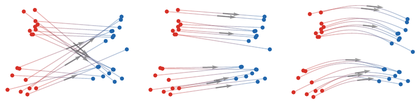

In [4]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/generative-flow-matching-interpolants.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/generative-flow-matching-interpolants.png")
display(Image(filename=str(_thumb)))
